### Install Required Dependencies

In [ ]:
#! pip install git+https://github.com/huggingface/transformers accelerate pymupdf pillow numpy tqdm sentencepiece -q
#! pip install python-docx mistralai python-dotenv -q

### Imports

In [12]:
import csv
import gc
import html
import json
import math
import os
import re
import time
import unicodedata
from pathlib import Path

import fitz
import numpy as np
import torch
from PIL import Image, ImageOps, ImageFile
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoModelForImageTextToText,
    AutoProcessor,
    AutoTokenizer,
    LogitsProcessor,
    LogitsProcessorList,
)

### variables

In [13]:
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
GROUND_TRUTH_DIR = DATA_DIR / "ground-truth"
OCR_MODEL_ID = "zai-org/GLM-OCR"
LLM_MODEL_ID = "LiquidAI/LFM2.5-1.2B-Instruct"
DPI = 150
OCR_MAX_NEW_TOKENS = 4096
LLM_REFINE_MAX_NEW_TOKENS = 2048
LLM_TEMPERATURE = 0.7
LLM_TOP_K = 20
LLM_MIN_P = 0.0
LLM_TOP_P = 0.8
LLM_PRESENCE_PENALTY = 1.00
LLM_PALEOGRAPHY_NOTES = """
NOTES (apply when resolving OCR noise):
- u and v are used interchangeably — check against dictionary.
- f and s are used interchangeably — check against dictionary.
- accents are inconsistent — should be ignored (except ñ).
- some letters have horizontal "cap" — tends to mean n follows, or ue after capped q.
- some line end hyphens not present — leave words split for now, can decide later.
- ç old spelling is always modern z — interpret ç as z when consistent with context.
""".strip()
LLM_REFINE_SYSTEM_INSTRUCTIONS = (
    "You reconstruct early-modern handwritten text from noisy OCR. "
    "Output only the requested <final> block, no preamble or commentary.\n\n"
    + LLM_PALEOGRAPHY_NOTES
)
TEXT_SUFFIXES = {".txt", ".md", ".text"}
Image.MAX_IMAGE_PIXELS = None
ImageFile.LOAD_TRUNCATED_IMAGES = True

### Local OCR (`GLM-OCR`) and LLM (`Liquid2.5-1.2B-Instruct`)

In [ ]:
def ensure_dir(path):
    path.mkdir(parents=True, exist_ok=True)

def clean_spaces(text):
    text = text.replace("\u00ad", "")
    text = text.replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

def normalize_doc_stem(s):
    s = unicodedata.normalize("NFKC", s or "")
    s = s.lower()
    s = s.replace("&#x3a;", ":").replace("&#x3a", ":")
    s = re.sub(r":+", ".", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def _gt_base_stem(name_stem):
    suf = "_transcription"
    if name_stem.lower().endswith(suf):
        return name_stem[: -len(suf)]
    return name_stem

def strip_special(text):
    text = re.sub(r"<\|.*?\|>", " ", text)
    text = re.sub(r"</?s>", " ", text)
    text = re.sub(r"<image>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def normalize_eval(text):
    text = unicodedata.normalize("NFKC", text)
    text = text.replace("\u00ad", "")
    text = re.sub(r"-\s*\n\s*", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()

def levenshtein(a, b):
    if a == b:
        return 0
    if len(a) < len(b):
        a, b = b, a
    previous = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        current = [i]
        for j, cb in enumerate(b, 1):
            current.append(min(
                current[-1] + 1,
                previous[j] + 1,
                previous[j - 1] + (0 if ca == cb else 1)
            ))
        previous = current
    return previous[-1]

def cer(pred, gold):
    gold = normalize_eval(gold)
    pred = normalize_eval(pred)
    if not gold:
        return 0.0 if not pred else 1.0
    return levenshtein(pred, gold) / max(1, len(gold))

def wer(pred, gold):
    gold = normalize_eval(gold).split()
    pred = normalize_eval(pred).split()
    if not gold:
        return 0.0 if not pred else 1.0
    return levenshtein(pred, gold) / max(1, len(gold))

def exact_match_rate(pred, gold):
    gold_lines = [normalize_eval(x) for x in gold.splitlines() if x.strip()]
    pred_lines = [normalize_eval(x) for x in pred.splitlines() if x.strip()]
    if not gold_lines:
        return 0.0
    m = min(len(gold_lines), len(pred_lines))
    if m == 0:
        return 0.0
    matches = sum(1 for i in range(m) if gold_lines[i] == pred_lines[i])
    return matches / len(gold_lines)

def choose_prefix(pred, gold):
    pred_n = normalize_eval(pred)
    gold_n = normalize_eval(gold)
    if not pred_n:
        return ""
    target = len(gold_n)
    if target == 0:
        return pred_n
    lengths = set()
    for r in [0.55, 0.65, 0.75, 0.85, 0.95, 1.0, 1.05, 1.15, 1.25, 1.35]:
        lengths.add(max(1, min(len(pred_n), int(target * r))))
    lengths.add(min(len(pred_n), target))
    candidates = [pred_n[:k] for k in sorted(lengths)]
    best = min(candidates, key=lambda x: cer(x, gold_n))
    return best

def page_to_image(page, dpi):
    scale = dpi / 72.0
    pix = page.get_pixmap(matrix=fitz.Matrix(scale, scale), alpha=False)
    return Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

def crop_main_text(image):
    gray = ImageOps.grayscale(image)
    arr = np.array(gray)
    inv = 255 - arr
    mask = inv > 20
    if mask.sum() == 0:
        return image
    row_density = mask.mean(axis=1)
    col_density = mask.mean(axis=0)
    row_thresh = max(float(row_density.max()) * 0.12, 0.0025)
    col_thresh = max(float(col_density.max()) * 0.12, 0.0015)
    ys = np.where(row_density > row_thresh)[0]
    xs = np.where(col_density > col_thresh)[0]
    if len(xs) == 0 or len(ys) == 0:
        return image
    y0, y1 = int(ys[0]), int(ys[-1] + 1)
    x0, x1 = int(xs[0]), int(xs[-1] + 1)
    pad_y = max(10, int((y1 - y0) * 0.02))
    pad_x = max(10, int((x1 - x0) * 0.02))
    y0 = max(0, y0 - pad_y)
    y1 = min(image.height, y1 + pad_y)
    x0 = max(0, x0 - pad_x)
    x1 = min(image.width, x1 + pad_x)
    cropped = image.crop((x0, y0, x1, y1))
    return cropped

def split_bands(image, target_height=1200, overlap=150):
    w, h = image.size
    if h <= target_height:
        return [image]
    out = []
    y = 0
    while y < h:
        y2 = min(h, y + target_height)
        out.append(image.crop((0, y, w, y2)))
        if y2 >= h:
            break
        y = y2 - overlap
    return out

def render_pdf(pdf_path, out_dir, dpi=DPI):
    ensure_dir(out_dir)
    doc = fitz.open(pdf_path)
    pages = []
    stem = pdf_path.stem
    n_pages = len(doc)
    page_bar = tqdm(
        range(n_pages),
        desc=f"Render pages · {stem}",
        total=n_pages,
        unit="page",
        mininterval=0,
        leave=True,
        dynamic_ncols=True,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
    )
    for idx in page_bar:
        page_bar.set_postfix_str(f"page {idx + 1}/{n_pages}", refresh=True)
        page = doc[idx]
        img = page_to_image(page, dpi)
        img = crop_main_text(img)
        page_path = out_dir / f"page_{idx + 1:04d}.png"
        img.save(page_path)
        band_paths = []
        bands = split_bands(img)
        band_bar = tqdm(
            enumerate(bands, 1),
            total=len(bands),
            desc=f"Split bands · {stem} p{idx + 1}",
            unit="band",
            mininterval=0,
            leave=False,
            dynamic_ncols=True,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
        )
        for j, band in band_bar:
            band_path = out_dir / f"page_{idx + 1:04d}_band_{j:02d}.png"
            band.save(band_path)
            band_paths.append(str(band_path.resolve()))
        pages.append({
            "page_num": idx + 1,
            "image_path": str(page_path.resolve()),
            "band_paths": band_paths
        })
    doc.close()
    return pages

def find_ground_truth(pdf_path, data_dir):
    pdf_stem_norm = normalize_doc_stem(pdf_path.stem)
    roots = []
    for d in (GROUND_TRUTH_DIR, Path("ground-truth"), Path(data_dir)):
        if d.exists():
            r = d.resolve()
            if r not in roots:
                roots.append(r)
    seen_files = set()
    candidates = []
    for root in roots:
        for p in Path(root).rglob("*"):
            if not p.is_file():
                continue
            rp = p.resolve()
            if rp in seen_files:
                continue
            if p.suffix.lower() not in TEXT_SUFFIXES:
                continue
            seen_files.add(rp)
            base = _gt_base_stem(p.stem)
            if normalize_doc_stem(base) != pdf_stem_norm:
                continue
            score = 1000
            if "transcrib" in p.name.lower():
                score += 10
            if "ground-truth" in str(p.parent).lower():
                score += 15
            candidates.append((score, -len(str(p)), str(p)))
    if not candidates:
        return None
    candidates.sort(reverse=True)
    return Path(candidates[0][2])

def read_text(path):
    return Path(path).read_text(encoding="utf-8", errors="ignore")

def read_ground_truth(path):
    path = Path(path)
    if path.suffix.lower() == ".docx":
        try:
            from docx import Document
        except ImportError as e:
            raise ImportError("`pip install python-docx` to read .docx ground-truth files") from e
        doc = Document(path)
        return "\n".join(p.text for p in doc.paragraphs)
    return read_text(path)

def strip_ground_truth_notes(text):
    """Remove NOTES / Note header + PDF page markers so metrics match transcript only."""
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    t = text.strip()
    if not t:
        return t
    m = re.search(r"(?ms)^(?:NOTES|NOTA|NOTE)\s*:.*?^\s*PDF\s+p\d+\s*$", t)
    if m:
        t = t[m.end():].lstrip("\n")
    elif re.match(r"^(?:NOTES|NOTA|NOTE)\s*:", t, re.I):
        t = re.sub(r"(?ms)^(NOTES|NOTA|NOTE)\s*:.*?\n\n+", "", t, count=1)
    lines = []
    for line in t.split("\n"):
        if re.match(r"^\s*PDF\s+p\d+\s*$", line, re.I):
            continue
        lines.append(line)
    return "\n".join(lines).strip()

def load_json(path, default):
    path = Path(path)
    if path.exists():
        try:
            return json.loads(path.read_text(encoding="utf-8"))
        except Exception:
            return default
    return default

def save_json_atomic(path, data):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding="utf-8")
    tmp.replace(path)

class PresencePenaltyLogitsProcessor(LogitsProcessor):
    """Penalize logits of tokens already seen (OpenAI-style presence, scaled 0–2)."""

    def __init__(self, penalty: float):
        self.penalty = float(min(2.0, max(0.0, penalty)))

    def __call__(self, input_ids: torch.LongTensor, scores: torch.FloatTensor) -> torch.FloatTensor:
        if self.penalty == 0.0:
            return scores
        for tid in set(input_ids[0].tolist()):
            scores[:, tid] -= self.penalty
        return scores


class GLMOCR:
    def __init__(self, model_id):
        self.model_id = model_id
        self.processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
        self.model = AutoModelForImageTextToText.from_pretrained(
            model_id,
            torch_dtype="auto",
            device_map="auto",
            trust_remote_code=True
        )
        self.model.eval()

    def transcribe(self, image_path, prompt="Text Recognition:", max_new_tokens=OCR_MAX_NEW_TOKENS):
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "url": str(Path(image_path).resolve())},
                    {"type": "text", "text": prompt}
                ]
            }
        ]
        inputs = self.processor.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_dict=True,
            return_tensors="pt"
        )
        device = next(self.model.parameters()).device
        inputs = inputs.to(device)
        inputs.pop("token_type_ids", None)
        with torch.inference_mode():
            generated_ids = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False
            )
        text = self.processor.decode(
            generated_ids[0][inputs["input_ids"].shape[1]:],
            skip_special_tokens=False
        )
        return clean_spaces(strip_special(text))

    def unload(self):
        del self.model
        del self.processor
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

class Corrector:
    def __init__(self, model_id):
        self.model_id = model_id
        self.mode = None
        self.model = None
        self.tokenizer = None
        self.processor = None
        try:
            self.tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
            if self.tokenizer.pad_token_id is None and self.tokenizer.eos_token_id is not None:
                self.tokenizer.pad_token = self.tokenizer.eos_token
            self.model = AutoModelForCausalLM.from_pretrained(
                model_id,
                torch_dtype="auto",
                device_map="auto",
                trust_remote_code=True
            )
            self.model.eval()
            self.mode = "causal"
        except Exception:
            self.processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
            self.model = AutoModelForImageTextToText.from_pretrained(
                model_id,
                torch_dtype="auto",
                device_map="auto",
                trust_remote_code=True
            )
            self.model.eval()
            self.mode = "multimodal"

    def _extract_final(self, raw_text):
        m = re.search(r"<final>\s*(.*?)\s*</final>", raw_text, flags=re.IGNORECASE | re.DOTALL)
        if m:
            return clean_spaces(m.group(1))
        return ""

    def _refinement_corrupt(self, text, ocr_full):
        if not text or len(text) < 5:
            return True
        ocr_len = max(len(ocr_full), 80)
        if len(text) > ocr_len * 15:
            return True
        if text.count(">") > min(50, max(1, len(text) // 12)):
            return True
        n = len(text)
        if sum(c.isdigit() for c in text) / n > 0.2:
            return True
        if text.count("1") / n > 0.2:
            return True
        head = text[:1200].lower()
        if "hmm," in head or "this is a complex" in head or "chain of" in head:
            return True
        return False

    def generate(self, prompt, max_new_tokens=LLM_REFINE_MAX_NEW_TOKENS):
        gen_kw = dict(
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=LLM_TEMPERATURE,
            top_k=LLM_TOP_K,
            top_p=LLM_TOP_P,
        )
        if LLM_MIN_P > 0:
            gen_kw["min_p"] = LLM_MIN_P
        logits_processors = LogitsProcessorList()
        if LLM_PRESENCE_PENALTY > 0:
            logits_processors.append(PresencePenaltyLogitsProcessor(LLM_PRESENCE_PENALTY))
        if len(logits_processors) > 0:
            gen_kw["logits_processor"] = logits_processors
        if self.mode == "causal":
            messages = [
                {"role": "system", "content": LLM_REFINE_SYSTEM_INSTRUCTIONS},
                {"role": "user", "content": prompt}
            ]
            if hasattr(self.tokenizer, "apply_chat_template"):
                text = self.tokenizer.apply_chat_template(
                    messages,
                    tokenize=False,
                    add_generation_prompt=True
                )
            else:
                text = prompt
            inputs = self.tokenizer(text, return_tensors="pt")
            device = next(self.model.parameters()).device
            inputs = {k: v.to(device) for k, v in inputs.items()}
            pad_id = self.tokenizer.pad_token_id if self.tokenizer.pad_token_id is not None else self.tokenizer.eos_token_id
            with torch.inference_mode():
                generated = self.model.generate(
                    **inputs,
                    **gen_kw,
                    pad_token_id=pad_id if pad_id is not None else 0
                )
            out = self.tokenizer.decode(generated[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
            return self._extract_final(out)
        messages = [
            {"role": "system", "content": LLM_REFINE_SYSTEM_INSTRUCTIONS},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt}
                ]
            }
        ]
        inputs = self.processor.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_dict=True,
            return_tensors="pt"
        )
        device = next(self.model.parameters()).device
        inputs = inputs.to(device)
        inputs.pop("token_type_ids", None)
        with torch.inference_mode():
            generated_ids = self.model.generate(
                **inputs,
                **gen_kw
            )
        out = self.processor.decode(
            generated_ids[0][inputs["input_ids"].shape[1]:],
            skip_special_tokens=False
        )
        return self._extract_final(strip_special(out))

    def refine_page(self, full_page_text, band_texts, prev_tail):
        band_block = "\n\n".join(
            f"[Band {i + 1}]\n{clean_spaces(x)}"
            for i, x in enumerate(band_texts) if clean_spaces(x)
        )
        prompt = f"""
Reconstruct the best transcription for one handwritten page from noisy OCR candidates.

{LLM_PALEOGRAPHY_NOTES}

Rules:
1. Keep reading order.
2. Preserve historical spelling when plausible.
3. Do not modernize the language.
4. Do not invent missing words.
5. If a span is unreadable, write [UNCLEAR].
6. Use previous-page context only for obvious disambiguation.
7. Return only this format:

<final>
YOUR TRANSCRIPTION
</final>

Previous page tail:
{prev_tail}

Full-page OCR:
{full_page_text}

Band OCR candidates:
{band_block}
""".strip()
        refined = self.generate(prompt)
        if not refined or self._refinement_corrupt(refined, full_page_text):
            return clean_spaces(full_page_text)
        return refined

    def unload(self):
        if self.model is not None:
            del self.model
        if self.tokenizer is not None:
            del self.tokenizer
        if self.processor is not None:
            del self.processor
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

def join_pages(pages, key):
    texts = []
    for page in pages:
        texts.append(clean_spaces(page.get(key, "")))
    return "\n\n".join([x for x in texts if x.strip()])

def _ocr_checkpoint_ok(item):
    raw_path = Path(item["work_dir"]) / "raw_ocr.json"
    existing = load_json(raw_path, None)
    pages = item.get("pages") or []
    return (
        existing is not None
        and len(pages) > 0
        and len(existing) == len(pages)
    )

def _correction_checkpoint_ok(item):
    wd = Path(item["work_dir"])
    return (wd / "corrected.json").exists() and (wd / "transcript.txt").exists()

def ocr_stage(dataset_manifest):
    if dataset_manifest and all(_ocr_checkpoint_ok(it) for it in dataset_manifest):
        tqdm.write("Skipping OCR: raw_ocr.json is complete for all documents under outputs.")
        return
    tqdm.write("Loading vision OCR model (GLM-OCR)…")
    ocr = GLMOCR(OCR_MODEL_ID)
    dataset_bar = tqdm(
        dataset_manifest,
        desc="OCR · by document",
        unit="doc",
        dynamic_ncols=True,
        mininterval=0,
        leave=True,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
    )
    for item in dataset_bar:
        name = item["name"]
        dataset_bar.set_postfix_str(str(name), refresh=True)
        raw_path = Path(item["work_dir"]) / "raw_ocr.json"
        progress_path = Path(item["work_dir"]) / "raw_ocr_progress.json"
        existing = load_json(raw_path, None)
        if existing is not None and len(existing) == len(item["pages"]):
            tqdm.write(f"Skipping OCR (already done): {name}")
            continue
        page_results = load_json(progress_path, [])
        done_pages = {x["page_num"] for x in page_results if "page_num" in x}
        pending = [p for p in item["pages"] if p["page_num"] not in done_pages]
        if not pending:
            save_json_atomic(raw_path, sorted(page_results, key=lambda x: x["page_num"]))
            continue
        page_bar = tqdm(
            pending,
            desc=f"OCR pages · {name}",
            total=len(pending),
            unit="page",
            mininterval=0,
            leave=True,
            dynamic_ncols=True,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
        )
        for page in page_bar:
            pn = page["page_num"]
            page_bar.set_postfix_str(f"page {pn}/{len(item['pages'])}", refresh=True)
            full_text = ocr.transcribe(page["image_path"])
            band_texts = []
            n_bands = len(page["band_paths"])
            band_bar = tqdm(
                page["band_paths"],
                desc=f"OCR bands · {name} p{pn}",
                total=n_bands,
                unit="band",
                mininterval=0,
                leave=False,
                dynamic_ncols=True,
                bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
            )
            for band_path in band_bar:
                band_texts.append(ocr.transcribe(band_path))
            page_results.append({
                "page_num": page["page_num"],
                "image_path": page["image_path"],
                "band_paths": page["band_paths"],
                "ocr_full": full_text,
                "ocr_bands": band_texts
            })
            page_results = sorted(page_results, key=lambda x: x["page_num"])
            save_json_atomic(progress_path, page_results)
        save_json_atomic(raw_path, sorted(page_results, key=lambda x: x["page_num"]))
    ocr.unload()

def correction_stage(dataset_manifest):
    if dataset_manifest and all(_correction_checkpoint_ok(it) for it in dataset_manifest):
        tqdm.write("Skipping correction: corrected.json and transcript.txt exist for all documents under outputs.")
        return
    tqdm.write("Loading LLM for correction (this can take a while)…")
    llm = Corrector(LLM_MODEL_ID)
    dataset_bar = tqdm(
        dataset_manifest,
        desc="Correction · by document",
        unit="doc",
        dynamic_ncols=True,
        mininterval=0,
        leave=True,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
    )
    for item in dataset_bar:
        name = item["name"]
        dataset_bar.set_postfix_str(str(name), refresh=True)
        raw_path = Path(item["work_dir"]) / "raw_ocr.json"
        corrected_path = Path(item["work_dir"]) / "corrected.json"
        corrected_progress_path = Path(item["work_dir"]) / "corrected_progress.json"
        transcript_path = Path(item["work_dir"]) / "transcript.txt"
        if corrected_path.exists() and transcript_path.exists():
            tqdm.write(f"Skipping correction (already done): {name}")
            continue
        pages = load_json(raw_path, [])
        corrected = load_json(corrected_progress_path, [])
        corrected_map = {x["page_num"]: x for x in corrected if "page_num" in x}
        ordered_corrected = []
        prev_tail = ""
        n_pages = len(pages)
        initial_done = sum(1 for p in pages if p["page_num"] in corrected_map)
        page_bar = tqdm(
            pages,
            desc=f"LLM pages · {name}",
            total=n_pages,
            initial=initial_done,
            unit="page",
            mininterval=0,
            leave=True,
            dynamic_ncols=True,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
        )
        for page in page_bar:
            page_num = page["page_num"]
            page_bar.set_postfix_str(f"page {page_num}/{n_pages}", refresh=True)
            if page_num in corrected_map:
                existing_page = corrected_map[page_num]
                ordered_corrected.append(existing_page)
                prev_tail = (prev_tail + "\n" + existing_page.get("corrected", ""))[-2000:]
                continue
            refined = llm.refine_page(page["ocr_full"], page["ocr_bands"], prev_tail[-1000:])
            page["corrected"] = refined
            corrected_map[page_num] = page
            ordered_corrected.append(page)
            prev_tail = (prev_tail + "\n" + refined)[-2000:]
            save_json_atomic(corrected_progress_path, sorted(corrected_map.values(), key=lambda x: x["page_num"]))
            partial_transcript = join_pages(sorted(corrected_map.values(), key=lambda x: x["page_num"]), "corrected")
            transcript_path.write_text(partial_transcript, encoding="utf-8")
        final_corrected = sorted(corrected_map.values(), key=lambda x: x["page_num"])
        save_json_atomic(corrected_path, final_corrected)
        transcript = join_pages(final_corrected, "corrected")
        transcript_path.write_text(transcript, encoding="utf-8")
    llm.unload()

def evaluate_stage(dataset_manifest):
    summary_rows = []
    summary_json = []
    dataset_bar = tqdm(
        dataset_manifest,
        desc="Evaluate · by document",
        unit="doc",
        dynamic_ncols=True,
        mininterval=0,
        leave=True,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
    )
    for item in dataset_bar:
        dataset_bar.set_postfix_str(str(item["name"]), refresh=True)
        work_dir = Path(item["work_dir"])
        corrected_path = work_dir / "corrected.json"
        corrected = json.loads(corrected_path.read_text(encoding="utf-8"))
        raw_text = join_pages(corrected, "ocr_full")
        corrected_text = join_pages(corrected, "corrected")
        gt_path = find_ground_truth(Path(item["pdf_path"]), DATA_DIR)
        result = {
            "source": item["name"],
            "pdf_path": item["pdf_path"],
            "gt_path": str(gt_path) if gt_path else None,
            "pages": len(corrected),
            "raw_text_path": str(work_dir / "raw_ocr.json"),
            "corrected_text_path": str(work_dir / "transcript.txt")
        }
        if gt_path is not None:
            gt = strip_ground_truth_notes(read_ground_truth(gt_path))
            raw_prefix = choose_prefix(raw_text, gt)
            corrected_prefix = choose_prefix(corrected_text, gt)
            metrics = {
                "raw_cer": cer(raw_prefix, gt),
                "raw_wer": wer(raw_prefix, gt),
                "raw_exact_line_rate": exact_match_rate(raw_prefix, gt),
                "corrected_cer": cer(corrected_prefix, gt),
                "corrected_wer": wer(corrected_prefix, gt),
                "corrected_exact_line_rate": exact_match_rate(corrected_prefix, gt)
            }
            result["metrics"] = metrics
            summary_rows.append({
                "source": item["name"],
                "pages": len(corrected),
                "gt_path": str(gt_path),
                "raw_cer": metrics["raw_cer"],
                "raw_wer": metrics["raw_wer"],
                "raw_exact_line_rate": metrics["raw_exact_line_rate"],
                "corrected_cer": metrics["corrected_cer"],
                "corrected_wer": metrics["corrected_wer"],
                "corrected_exact_line_rate": metrics["corrected_exact_line_rate"]
            })
        else:
            result["metrics"] = None
            summary_rows.append({
                "source": item["name"],
                "pages": len(corrected),
                "gt_path": "",
                "raw_cer": "",
                "raw_wer": "",
                "raw_exact_line_rate": "",
                "corrected_cer": "",
                "corrected_wer": "",
                "corrected_exact_line_rate": ""
            })
        summary_json.append(result)
        (work_dir / "result.json").write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
    ensure_dir(OUTPUT_DIR)
    with tqdm(total=2, desc="Write outputs", leave=False, dynamic_ncols=True) as write_bar:
        with (OUTPUT_DIR / "summary.csv").open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(
                f,
                fieldnames=[
                    "source",
                    "pages",
                    "gt_path",
                    "raw_cer",
                    "raw_wer",
                    "raw_exact_line_rate",
                    "corrected_cer",
                    "corrected_wer",
                    "corrected_exact_line_rate"
                ]
            )
            writer.writeheader()
            writer.writerows(summary_rows)
        write_bar.set_postfix(file="summary.csv", refresh=False)
        write_bar.update(1)
        (OUTPUT_DIR / "summary.json").write_text(json.dumps(summary_json, ensure_ascii=False, indent=2), encoding="utf-8")
        write_bar.set_postfix(file="summary.json", refresh=False)
        write_bar.update(1)

def build_manifest():
    ensure_dir(OUTPUT_DIR)
    pdfs = sorted(DATA_DIR.rglob("*.pdf"))
    manifest = []
    pdf_bar = tqdm(
        pdfs,
        desc="Manifest · PDFs",
        total=len(pdfs),
        unit="pdf",
        dynamic_ncols=True,
        mininterval=0,
        leave=True,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
    )
    for pdf_path in pdf_bar:
        name = pdf_path.stem
        pdf_bar.set_postfix_str(str(name), refresh=True)
        work_dir = OUTPUT_DIR / name
        images_dir = work_dir / "pages"
        if not images_dir.exists() or not any(images_dir.glob("page_*.png")):
            pages = render_pdf(pdf_path, images_dir, dpi=DPI)
        else:
            pages = []
            page_paths = sorted([p for p in images_dir.glob("page_*.png") if "_band_" not in p.name])
            page_bar = tqdm(
                page_paths,
                desc=f"Scan pages · {name}",
                total=len(page_paths),
                unit="page",
                mininterval=0,
                leave=True,
                dynamic_ncols=True,
                bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
            )
            for page_path in page_bar:
                m = re.search(r"page_(\d+)\.png$", page_path.name)
                page_num = int(m.group(1))
                band_paths = sorted(images_dir.glob(f"page_{page_num:04d}_band_*.png"))
                pages.append({
                    "page_num": page_num,
                    "image_path": str(page_path.resolve()),
                    "band_paths": [str(x.resolve()) for x in band_paths]
                })
        manifest.append({
            "name": name,
            "pdf_path": str(pdf_path.resolve()),
            "work_dir": str(work_dir.resolve()),
            "pages": pages
        })
    return manifest

In [15]:
def main():
    ensure_dir(OUTPUT_DIR)
    t_run = time.perf_counter()
    tqdm.write("─── [1/4] Building manifest ───")
    t0 = time.perf_counter()
    manifest = build_manifest()
    if not manifest:
        raise FileNotFoundError("No PDF files found under data/")
    (OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
    tqdm.write(f"Manifest: {len(manifest)} document(s) in {time.perf_counter() - t0:.1f}s")
    tqdm.write("─── [2/4] OCR (GLM-OCR) ───")
    t0 = time.perf_counter()
    ocr_stage(manifest)
    tqdm.write(f"OCR stage finished in {time.perf_counter() - t0:.1f}s")
    tqdm.write("─── [3/4] Correction (LLM) ───")
    t0 = time.perf_counter()
    correction_stage(manifest)
    tqdm.write(f"Correction stage finished in {time.perf_counter() - t0:.1f}s")
    tqdm.write("─── [4/4] Evaluation ───")
    t0 = time.perf_counter()
    evaluate_stage(manifest)
    tqdm.write(f"Evaluation finished in {time.perf_counter() - t0:.1f}s")
    print(f"Done in {time.perf_counter() - t_run:.1f}s. Outputs saved to {OUTPUT_DIR.resolve()}")

main()

─── [1/4] Building manifest ───


Manifest · PDFs: 100%|██████████| 5/5 [00:00<00:00] , doc5

Manifest: 5 document(s) in 0.1s
─── [2/4] OCR (GLM-OCR) ───
Skipping OCR: raw_ocr.json is complete for all documents under outputs.
OCR stage finished in 0.0s
─── [3/4] Correction (LLM) ───
Loading LLM for correction (this can take a while)…



Correction · by document: 100%|██████████| 5/5 [09:27<00:00] , doc5


Correction stage finished in 571.5s
─── [4/4] Evaluation ───


Evaluate · by document: 100%|██████████| 5/5 [00:31<00:00] , doc5
                                                    

Evaluation finished in 31.7s
Done in 603.3s. Outputs saved to C:\Users\aarus\Desktop\ocr\outputs


### Mistral API (`mistral-large-latest`)

Run **after** the variables + pipeline function cells above. Loads `MISTRAL_API_KEY` from `.env` (project root).

Writes per document: `corrected_mistral.json`, `transcript_mistral.txt`, and under `outputs/`: `summary_mistral_api.csv`, `summary_mistral_api.json` — same metrics layout as the local LLM summary, for side‑by‑side comparison.


In [16]:
! pip install mistralai python-dotenv -q

In [17]:
from pathlib import Path
import json
import os
import time

from dotenv import load_dotenv

try:
    from mistralai import Mistral
except ImportError:
    try:
        from mistralai.client import Mistral
    except ImportError as e:
        raise ImportError("Install: pip install mistralai python-dotenv") from e

load_dotenv(Path(".env"))
MISTRAL_API_KEY = (os.environ.get("MISTRAL_API_KEY") or "").strip().strip('"').strip("'")
MISTRAL_MODEL = "mistral-large-latest"

if not MISTRAL_API_KEY:
    raise RuntimeError("Set MISTRAL_API_KEY in .env (project root)")


class MistralAPICorrector:
    def __init__(self):
        self.client = Mistral(api_key=MISTRAL_API_KEY)

    def _extract_final(self, raw_text):
        m = re.search(r"<final>\s*(.*?)\s*</final>", raw_text, flags=re.IGNORECASE | re.DOTALL)
        if m:
            return clean_spaces(m.group(1))
        return ""

    def _refinement_corrupt(self, text, ocr_full):
        if not text or len(text) < 5:
            return True
        ocr_len = max(len(ocr_full), 80)
        if len(text) > ocr_len * 15:
            return True
        if text.count(">") > min(50, max(1, len(text) // 12)):
            return True
        n = len(text)
        if sum(c.isdigit() for c in text) / n > 0.2:
            return True
        if text.count("1") / n > 0.2:
            return True
        head = text[:1200].lower()
        if "hmm," in head or "this is a complex" in head or "chain of" in head:
            return True
        return False

    def refine_page(self, full_page_text, band_texts, prev_tail):
        band_block = "\n\n".join(
            f"[Band {i + 1}]\n{clean_spaces(x)}"
            for i, x in enumerate(band_texts) if clean_spaces(x)
        )
        prompt = f"""
Reconstruct the best transcription for one handwritten page from noisy OCR candidates.

{LLM_PALEOGRAPHY_NOTES}

Rules:
1. Keep reading order.
2. Preserve historical spelling when plausible.
3. Do not modernize the language.
4. Do not invent missing words.
5. If a span is unreadable, write [UNCLEAR].
6. Use previous-page context only for obvious disambiguation.
7. Return only this format:

<final>
YOUR TRANSCRIPTION
</final>

Previous page tail:
{prev_tail}

Full-page OCR:
{full_page_text}

Band OCR candidates:
{band_block}
""".strip()
        chat_response = self.client.chat.complete(
            model=MISTRAL_MODEL,
            messages=[
                {"role": "system", "content": LLM_REFINE_SYSTEM_INSTRUCTIONS},
                {"role": "user", "content": prompt},
            ],
            temperature=LLM_TEMPERATURE,
            max_tokens=LLM_REFINE_MAX_NEW_TOKENS,
            top_p=LLM_TOP_P,
        )
        msg = chat_response.choices[0].message
        out = getattr(msg, "content", None)
        if out is None:
            out = ""
        elif isinstance(out, list):
            out = "".join(
                (p.get("text", "") if isinstance(p, dict) else str(p)) for p in out
            )
        refined = self._extract_final(out)
        if not refined or self._refinement_corrupt(refined, full_page_text):
            return clean_spaces(full_page_text)
        return refined


def _mistral_api_checkpoint_ok(item):
    wd = Path(item["work_dir"])
    return (wd / "corrected_mistral.json").exists() and (wd / "transcript_mistral.txt").exists()


def join_pages_mistral(pages):
    texts = []
    for page in pages:
        texts.append(clean_spaces(page.get("corrected_mistral", "")))
    return "\n\n".join([x for x in texts if x.strip()])


def correction_stage_mistral_api(dataset_manifest):
    if dataset_manifest and all(_mistral_api_checkpoint_ok(it) for it in dataset_manifest):
        tqdm.write("Skipping Mistral API correction: outputs already present for all documents.")
        return
    tqdm.write(f"Calling Mistral API ({MISTRAL_MODEL})…")
    llm = MistralAPICorrector()
    dataset_bar = tqdm(
        dataset_manifest,
        desc="Mistral API · by document",
        unit="doc",
        dynamic_ncols=True,
        mininterval=0,
        leave=True,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
    )
    for item in dataset_bar:
        name = item["name"]
        dataset_bar.set_postfix_str(str(name), refresh=True)
        raw_path = Path(item["work_dir"]) / "raw_ocr.json"
        corrected_path = Path(item["work_dir"]) / "corrected_mistral.json"
        progress_path = Path(item["work_dir"]) / "corrected_mistral_progress.json"
        transcript_path = Path(item["work_dir"]) / "transcript_mistral.txt"
        if corrected_path.exists() and transcript_path.exists():
            tqdm.write(f"Skipping Mistral API (already done): {name}")
            continue
        pages = load_json(raw_path, [])
        corrected = load_json(progress_path, [])
        corrected_map = {x["page_num"]: x for x in corrected if "page_num" in x}
        prev_tail = ""
        n_pages = len(pages)
        initial_done = sum(1 for p in pages if p["page_num"] in corrected_map)
        page_bar = tqdm(
            pages,
            desc=f"Mistral pages · {name}",
            total=n_pages,
            initial=initial_done,
            unit="page",
            mininterval=0,
            leave=True,
            dynamic_ncols=True,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
        )
        for page in page_bar:
            page_num = page["page_num"]
            page_bar.set_postfix_str(f"page {page_num}/{n_pages}", refresh=True)
            if page_num in corrected_map:
                existing = corrected_map[page_num]
                prev_tail = (prev_tail + "\n" + existing.get("corrected_mistral", ""))[-2000:]
                continue
            refined = llm.refine_page(page["ocr_full"], page["ocr_bands"], prev_tail[-1000:])
            page["corrected_mistral"] = refined
            corrected_map[page_num] = page
            prev_tail = (prev_tail + "\n" + refined)[-2000:]
            save_json_atomic(progress_path, sorted(corrected_map.values(), key=lambda x: x["page_num"]))
            partial = join_pages_mistral(sorted(corrected_map.values(), key=lambda x: x["page_num"]))
            transcript_path.write_text(partial, encoding="utf-8")
            time.sleep(0.05)
        final_rows = sorted(corrected_map.values(), key=lambda x: x["page_num"])
        save_json_atomic(corrected_path, final_rows)
        transcript_path.write_text(join_pages_mistral(final_rows), encoding="utf-8")


def evaluate_stage_mistral_api(dataset_manifest):
    summary_rows = []
    summary_json = []
    dataset_bar = tqdm(
        dataset_manifest,
        desc="Evaluate Mistral API · by document",
        unit="doc",
        dynamic_ncols=True,
        mininterval=0,
        leave=True,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
    )
    for item in dataset_bar:
        dataset_bar.set_postfix_str(str(item["name"]), refresh=True)
        work_dir = Path(item["work_dir"])
        api_path = work_dir / "corrected_mistral.json"
        if not api_path.exists():
            tqdm.write(f"Skip eval (no {api_path.name}): {item['name']}")
            summary_rows.append({
                "source": item["name"],
                "pages": "",
                "gt_path": "",
                "raw_cer": "",
                "raw_wer": "",
                "raw_exact_line_rate": "",
                "mistral_cer": "",
                "mistral_wer": "",
                "mistral_exact_line_rate": "",
            })
            summary_json.append({"source": item["name"], "error": "missing corrected_mistral.json"})
            continue
        corrected = json.loads(api_path.read_text(encoding="utf-8"))
        raw_text = join_pages(corrected, "ocr_full")
        api_text = join_pages_mistral(corrected)
        gt_path = find_ground_truth(Path(item["pdf_path"]), DATA_DIR)
        result = {
            "source": item["name"],
            "pdf_path": item["pdf_path"],
            "gt_path": str(gt_path) if gt_path else None,
            "pages": len(corrected),
            "raw_text_path": str(work_dir / "raw_ocr.json"),
            "mistral_corrected_path": str(api_path),
            "mistral_transcript_path": str(work_dir / "transcript_mistral.txt"),
            "model": MISTRAL_MODEL,
        }
        if gt_path is not None:
            gt = strip_ground_truth_notes(read_ground_truth(gt_path))
            raw_prefix = choose_prefix(raw_text, gt)
            api_prefix = choose_prefix(api_text, gt)
            metrics = {
                "raw_cer": cer(raw_prefix, gt),
                "raw_wer": wer(raw_prefix, gt),
                "raw_exact_line_rate": exact_match_rate(raw_prefix, gt),
                "mistral_cer": cer(api_prefix, gt),
                "mistral_wer": wer(api_prefix, gt),
                "mistral_exact_line_rate": exact_match_rate(api_prefix, gt),
            }
            result["metrics"] = metrics
            summary_rows.append({
                "source": item["name"],
                "pages": len(corrected),
                "gt_path": str(gt_path),
                "raw_cer": metrics["raw_cer"],
                "raw_wer": metrics["raw_wer"],
                "raw_exact_line_rate": metrics["raw_exact_line_rate"],
                "mistral_cer": metrics["mistral_cer"],
                "mistral_wer": metrics["mistral_wer"],
                "mistral_exact_line_rate": metrics["mistral_exact_line_rate"],
            })
        else:
            result["metrics"] = None
            summary_rows.append({
                "source": item["name"],
                "pages": len(corrected),
                "gt_path": "",
                "raw_cer": "",
                "raw_wer": "",
                "raw_exact_line_rate": "",
                "mistral_cer": "",
                "mistral_wer": "",
                "mistral_exact_line_rate": "",
            })
        summary_json.append(result)
        (work_dir / "result_mistral_api.json").write_text(
            json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8"
        )
    ensure_dir(OUTPUT_DIR)
    with tqdm(total=2, desc="Write Mistral summaries", leave=False, dynamic_ncols=True) as write_bar:
        with (OUTPUT_DIR / "summary_mistral_api.csv").open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(
                f,
                fieldnames=[
                    "source",
                    "pages",
                    "gt_path",
                    "raw_cer",
                    "raw_wer",
                    "raw_exact_line_rate",
                    "mistral_cer",
                    "mistral_wer",
                    "mistral_exact_line_rate",
                ],
            )
            writer.writeheader()
            writer.writerows(summary_rows)
        write_bar.update(1)
        (OUTPUT_DIR / "summary_mistral_api.json").write_text(
            json.dumps(summary_json, ensure_ascii=False, indent=2), encoding="utf-8"
        )
        write_bar.update(1)


def run_mistral_api_compare():
    manifest_path = OUTPUT_DIR / "manifest.json"
    if not manifest_path.exists():
        raise FileNotFoundError(f"Missing {manifest_path}; run build_manifest / main pipeline first.")
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    t0 = time.perf_counter()
    tqdm.write("─── Mistral API correction ───")
    correction_stage_mistral_api(manifest)
    tqdm.write(f"Mistral correction finished in {time.perf_counter() - t0:.1f}s")
    t0 = time.perf_counter()
    tqdm.write("─── Evaluate Mistral API outputs ───")
    evaluate_stage_mistral_api(manifest)
    tqdm.write(f"Mistral evaluation finished in {time.perf_counter() - t0:.1f}s")
    print(f"Mistral comparison saved: {OUTPUT_DIR / 'summary_mistral_api.csv'}")


run_mistral_api_compare()

─── Mistral API correction ───
Calling Mistral API (mistral-large-latest)…


Mistral API · by document: 100%|██████████| 5/5 [06:56<00:00] , doc5


Mistral correction finished in 416.6s
─── Evaluate Mistral API outputs ───


Evaluate Mistral API · by document: 100%|██████████| 5/5 [00:38<00:00] , doc5
                                                              

Mistral evaluation finished in 38.7s
Mistral comparison saved: outputs\summary_mistral_api.csv


### OpenAI API (`gpt-5.4-nano`)

Uses `OPENAI_API_KEY` from `.env` and the same refine prompt as the local LLM.

Writes per document: `corrected_openai.json`, `transcript_openai.txt`, and under `outputs/`: `summary_openai_api.csv`, `summary_openai_api.json` — same metrics layout as the other summaries, with `openai_cer` / `openai_wer` / `openai_exact_line_rate`.


In [18]:
! pip install openai -q


In [19]:
from pathlib import Path
import json
import os
import time

from dotenv import load_dotenv

try:
    from openai import OpenAI
except ImportError as e:
    raise ImportError("Install: pip install openai python-dotenv") from e

load_dotenv(Path(".env"))
OPENAI_API_KEY = (os.environ.get("OPENAI_API_KEY") or "").strip().strip('"').strip("'")
OPENAI_MODEL = "gpt-5.4-nano"

if not OPENAI_API_KEY:
    raise RuntimeError("Set OPENAI_API_KEY in .env (project root)")


class OpenAIAPICorrector:
    def __init__(self):
        self.client = OpenAI(api_key=OPENAI_API_KEY)

    def _extract_final(self, raw_text):
        m = re.search(r"<final>\s*(.*?)\s*</final>", raw_text, flags=re.IGNORECASE | re.DOTALL)
        if m:
            return clean_spaces(m.group(1))
        return ""

    def _refinement_corrupt(self, text, ocr_full):
        if not text or len(text) < 5:
            return True
        ocr_len = max(len(ocr_full), 80)
        if len(text) > ocr_len * 15:
            return True
        if text.count(">") > min(50, max(1, len(text) // 12)):
            return True
        n = len(text)
        if sum(c.isdigit() for c in text) / n > 0.2:
            return True
        if text.count("1") / n > 0.2:
            return True
        head = text[:1200].lower()
        if "hmm," in head or "this is a complex" in head or "chain of" in head:
            return True
        return False

    def refine_page(self, full_page_text, band_texts, prev_tail):
        band_block = "\n\n".join(
            f"[Band {i + 1}]\n{clean_spaces(x)}"
            for i, x in enumerate(band_texts) if clean_spaces(x)
        )
        prompt = f"""
Reconstruct the best transcription for one handwritten page from noisy OCR candidates.

{LLM_PALEOGRAPHY_NOTES}

Rules:
1. Keep reading order.
2. Preserve historical spelling when plausible.
3. Do not modernize the language.
4. Do not invent missing words.
5. If a span is unreadable, write [UNCLEAR].
6. Use previous-page context only for obvious disambiguation.
7. Return only this format:

<final>
YOUR TRANSCRIPTION
</final>

Previous page tail:
{prev_tail}

Full-page OCR:
{full_page_text}

Band OCR candidates:
{band_block}
""".strip()
        chat_response = self.client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=[
                {"role": "system", "content": LLM_REFINE_SYSTEM_INSTRUCTIONS},
                {"role": "user", "content": prompt},
            ],
            temperature=LLM_TEMPERATURE,
            top_p=LLM_TOP_P,
            max_completion_tokens=LLM_REFINE_MAX_NEW_TOKENS,
        )
        msg = chat_response.choices[0].message
        out = getattr(msg, "content", None)
        if out is None:
            out = ""
        elif isinstance(out, list):
            out = "".join(
                (p.get("text", "") if isinstance(p, dict) else str(p)) for p in out
            )
        refined = self._extract_final(out)
        if not refined or self._refinement_corrupt(refined, full_page_text):
            return clean_spaces(full_page_text)
        return refined


def _openai_api_checkpoint_ok(item):
    wd = Path(item["work_dir"])
    return (wd / "corrected_openai.json").exists() and (wd / "transcript_openai.txt").exists()


def join_pages_openai(pages):
    texts = []
    for page in pages:
        texts.append(clean_spaces(page.get("corrected_openai", "")))
    return "\n\n".join([x for x in texts if x.strip()])


def correction_stage_openai_api(dataset_manifest):
    if dataset_manifest and all(_openai_api_checkpoint_ok(it) for it in dataset_manifest):
        tqdm.write("Skipping OpenAI API correction: outputs already present for all documents.")
        return
    tqdm.write(f"Calling OpenAI API ({OPENAI_MODEL})…")
    llm = OpenAIAPICorrector()
    dataset_bar = tqdm(
        dataset_manifest,
        desc="OpenAI API · by document",
        unit="doc",
        dynamic_ncols=True,
        mininterval=0,
        leave=True,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
    )
    for item in dataset_bar:
        name = item["name"]
        dataset_bar.set_postfix_str(str(name), refresh=True)
        raw_path = Path(item["work_dir"]) / "raw_ocr.json"
        corrected_path = Path(item["work_dir"]) / "corrected_openai.json"
        progress_path = Path(item["work_dir"]) / "corrected_openai_progress.json"
        transcript_path = Path(item["work_dir"]) / "transcript_openai.txt"
        if corrected_path.exists() and transcript_path.exists():
            tqdm.write(f"Skipping OpenAI API (already done): {name}")
            continue
        pages = load_json(raw_path, [])
        corrected = load_json(progress_path, [])
        corrected_map = {x["page_num"]: x for x in corrected if "page_num" in x}
        prev_tail = ""
        n_pages = len(pages)
        initial_done = sum(1 for p in pages if p["page_num"] in corrected_map)
        page_bar = tqdm(
            pages,
            desc=f"OpenAI pages · {name}",
            total=n_pages,
            initial=initial_done,
            unit="page",
            mininterval=0,
            leave=True,
            dynamic_ncols=True,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
        )
        for page in page_bar:
            page_num = page["page_num"]
            page_bar.set_postfix_str(f"page {page_num}/{n_pages}", refresh=True)
            if page_num in corrected_map:
                existing = corrected_map[page_num]
                prev_tail = (prev_tail + "\n" + existing.get("corrected_openai", ""))[-2000:]
                continue
            refined = llm.refine_page(page["ocr_full"], page["ocr_bands"], prev_tail[-1000:])
            page["corrected_openai"] = refined
            corrected_map[page_num] = page
            prev_tail = (prev_tail + "\n" + refined)[-2000:]
            save_json_atomic(progress_path, sorted(corrected_map.values(), key=lambda x: x["page_num"]))
            partial = join_pages_openai(sorted(corrected_map.values(), key=lambda x: x["page_num"]))
            transcript_path.write_text(partial, encoding="utf-8")
            time.sleep(0.05)
        final_rows = sorted(corrected_map.values(), key=lambda x: x["page_num"])
        save_json_atomic(corrected_path, final_rows)
        transcript_path.write_text(join_pages_openai(final_rows), encoding="utf-8")


def evaluate_stage_openai_api(dataset_manifest):
    summary_rows = []
    summary_json = []
    dataset_bar = tqdm(
        dataset_manifest,
        desc="Evaluate OpenAI API · by document",
        unit="doc",
        dynamic_ncols=True,
        mininterval=0,
        leave=True,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
    )
    for item in dataset_bar:
        dataset_bar.set_postfix_str(str(item["name"]), refresh=True)
        work_dir = Path(item["work_dir"])
        api_path = work_dir / "corrected_openai.json"
        if not api_path.exists():
            tqdm.write(f"Skip eval (no {api_path.name}): {item['name']}")
            summary_rows.append({
                "source": item["name"],
                "pages": "",
                "gt_path": "",
                "raw_cer": "",
                "raw_wer": "",
                "raw_exact_line_rate": "",
                "openai_cer": "",
                "openai_wer": "",
                "openai_exact_line_rate": "",
            })
            summary_json.append({"source": item["name"], "error": "missing corrected_openai.json"})
            continue
        corrected = json.loads(api_path.read_text(encoding="utf-8"))
        raw_text = join_pages(corrected, "ocr_full")
        api_text = join_pages_openai(corrected)
        gt_path = find_ground_truth(Path(item["pdf_path"]), DATA_DIR)
        result = {
            "source": item["name"],
            "pdf_path": item["pdf_path"],
            "gt_path": str(gt_path) if gt_path else None,
            "pages": len(corrected),
            "raw_text_path": str(work_dir / "raw_ocr.json"),
            "openai_corrected_path": str(api_path),
            "openai_transcript_path": str(work_dir / "transcript_openai.txt"),
            "model": OPENAI_MODEL,
        }
        if gt_path is not None:
            gt = strip_ground_truth_notes(read_ground_truth(gt_path))
            raw_prefix = choose_prefix(raw_text, gt)
            api_prefix = choose_prefix(api_text, gt)
            metrics = {
                "raw_cer": cer(raw_prefix, gt),
                "raw_wer": wer(raw_prefix, gt),
                "raw_exact_line_rate": exact_match_rate(raw_prefix, gt),
                "openai_cer": cer(api_prefix, gt),
                "openai_wer": wer(api_prefix, gt),
                "openai_exact_line_rate": exact_match_rate(api_prefix, gt),
            }
            result["metrics"] = metrics
            summary_rows.append({
                "source": item["name"],
                "pages": len(corrected),
                "gt_path": str(gt_path),
                "raw_cer": metrics["raw_cer"],
                "raw_wer": metrics["raw_wer"],
                "raw_exact_line_rate": metrics["raw_exact_line_rate"],
                "openai_cer": metrics["openai_cer"],
                "openai_wer": metrics["openai_wer"],
                "openai_exact_line_rate": metrics["openai_exact_line_rate"],
            })
        else:
            result["metrics"] = None
            summary_rows.append({
                "source": item["name"],
                "pages": len(corrected),
                "gt_path": "",
                "raw_cer": "",
                "raw_wer": "",
                "raw_exact_line_rate": "",
                "openai_cer": "",
                "openai_wer": "",
                "openai_exact_line_rate": "",
            })
        summary_json.append(result)
        (work_dir / "result_openai_api.json").write_text(
            json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8"
        )
    ensure_dir(OUTPUT_DIR)
    with tqdm(total=2, desc="Write OpenAI summaries", leave=False, dynamic_ncols=True) as write_bar:
        with (OUTPUT_DIR / "summary_openai_api.csv").open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(
                f,
                fieldnames=[
                    "source",
                    "pages",
                    "gt_path",
                    "raw_cer",
                    "raw_wer",
                    "raw_exact_line_rate",
                    "openai_cer",
                    "openai_wer",
                    "openai_exact_line_rate",
                ],
            )
            writer.writeheader()
            writer.writerows(summary_rows)
        write_bar.update(1)
        (OUTPUT_DIR / "summary_openai_api.json").write_text(
            json.dumps(summary_json, ensure_ascii=False, indent=2), encoding="utf-8"
        )
        write_bar.update(1)


def run_openai_api_compare():
    manifest_path = OUTPUT_DIR / "manifest.json"
    if not manifest_path.exists():
        raise FileNotFoundError(f"Missing {manifest_path}; run build_manifest / main pipeline first.")
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    t0 = time.perf_counter()
    tqdm.write("─── OpenAI API correction ───")
    correction_stage_openai_api(manifest)
    tqdm.write(f"OpenAI correction finished in {time.perf_counter() - t0:.1f}s")
    t0 = time.perf_counter()
    tqdm.write("─── Evaluate OpenAI API outputs ───")
    evaluate_stage_openai_api(manifest)
    tqdm.write(f"OpenAI evaluation finished in {time.perf_counter() - t0:.1f}s")
    print(f"OpenAI comparison saved: {OUTPUT_DIR / 'summary_openai_api.csv'}")


run_openai_api_compare()


─── OpenAI API correction ───
Calling OpenAI API (gpt-5.4-nano)…


OpenAI API · by document: 100%|██████████| 5/5 [01:57<00:00] , doc5


OpenAI correction finished in 117.5s
─── Evaluate OpenAI API outputs ───


Evaluate OpenAI API · by document: 100%|██████████| 5/5 [00:32<00:00] , doc5
                                                             

OpenAI evaluation finished in 32.9s
OpenAI comparison saved: outputs\summary_openai_api.csv


### OpenRouter (`nvidia/nemotron-3-super-120b-a12b:free`)

Uses `OPENROUTER_API_KEY` from `.env` via the [OpenRouter](https://openrouter.ai/) OpenAI-compatible API (`https://openrouter.ai/api/v1`). Same refine prompt as the local LLM.

Writes per document: `corrected_openrouter.json`, `transcript_openrouter.txt`, and under `outputs/`: `summary_openrouter_api.csv`, `summary_openrouter_api.json` — with `openrouter_cer` / `openrouter_wer` / `openrouter_exact_line_rate`.


In [24]:
from pathlib import Path
import json
import os
import time

from dotenv import load_dotenv

try:
    from openai import OpenAI
except ImportError as e:
    raise ImportError("Install: pip install openai python-dotenv") from e

load_dotenv(Path(".env"))
OPENROUTER_API_KEY = (os.environ.get("OPENROUTER_API_KEY") or "").strip().strip('"').strip("'")
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"
OPENROUTER_MODEL = "nvidia/nemotron-3-super-120b-a12b:free"

if not OPENROUTER_API_KEY:
    raise RuntimeError("Set OPENROUTER_API_KEY in .env (project root)")


class OpenRouterAPICorrector:
    def __init__(self):
        self.client = OpenAI(
            base_url=OPENROUTER_BASE_URL,
            api_key=OPENROUTER_API_KEY,
            default_headers={"X-Title": "ocr-notebook"},
        )

    def _extract_final(self, raw_text):
        m = re.search(r"<final>\s*(.*?)\s*</final>", raw_text, flags=re.IGNORECASE | re.DOTALL)
        if m:
            return clean_spaces(m.group(1))
        return ""

    def _refinement_corrupt(self, text, ocr_full):
        if not text or len(text) < 5:
            return True
        ocr_len = max(len(ocr_full), 80)
        if len(text) > ocr_len * 15:
            return True
        if text.count(">") > min(50, max(1, len(text) // 12)):
            return True
        n = len(text)
        if sum(c.isdigit() for c in text) / n > 0.2:
            return True
        if text.count("1") / n > 0.2:
            return True
        head = text[:1200].lower()
        if "hmm," in head or "this is a complex" in head or "chain of" in head:
            return True
        return False

    def refine_page(self, full_page_text, band_texts, prev_tail):
        band_block = "\n\n".join(
            f"[Band {i + 1}]\n{clean_spaces(x)}"
            for i, x in enumerate(band_texts) if clean_spaces(x)
        )
        prompt = f"""
Reconstruct the best transcription for one handwritten page from noisy OCR candidates.

{LLM_PALEOGRAPHY_NOTES}

Rules:
1. Keep reading order.
2. Preserve historical spelling when plausible.
3. Do not modernize the language.
4. Do not invent missing words.
5. If a span is unreadable, write [UNCLEAR].
6. Use previous-page context only for obvious disambiguation.
7. Return only this format:

<final>
YOUR TRANSCRIPTION
</final>

Previous page tail:
{prev_tail}

Full-page OCR:
{full_page_text}

Band OCR candidates:
{band_block}
""".strip()
        chat_response = self.client.chat.completions.create(
            model=OPENROUTER_MODEL,
            messages=[
                {"role": "system", "content": LLM_REFINE_SYSTEM_INSTRUCTIONS},
                {"role": "user", "content": prompt},
            ],
            temperature=LLM_TEMPERATURE,
            top_p=LLM_TOP_P,
            max_completion_tokens=LLM_REFINE_MAX_NEW_TOKENS,
        )
        msg = chat_response.choices[0].message
        out = getattr(msg, "content", None)
        if out is None:
            out = ""
        elif isinstance(out, list):
            out = "".join(
                (p.get("text", "") if isinstance(p, dict) else str(p)) for p in out
            )
        refined = self._extract_final(out)
        if not refined or self._refinement_corrupt(refined, full_page_text):
            return clean_spaces(full_page_text)
        return refined


def _openrouter_api_checkpoint_ok(item):
    wd = Path(item["work_dir"])
    return (wd / "corrected_openrouter.json").exists() and (wd / "transcript_openrouter.txt").exists()


def join_pages_openrouter(pages):
    texts = []
    for page in pages:
        texts.append(clean_spaces(page.get("corrected_openrouter", "")))
    return "\n\n".join([x for x in texts if x.strip()])


def correction_stage_openrouter_api(dataset_manifest):
    if dataset_manifest and all(_openrouter_api_checkpoint_ok(it) for it in dataset_manifest):
        tqdm.write("Skipping OpenRouter API correction: outputs already present for all documents.")
        return
    tqdm.write(f"Calling OpenRouter ({OPENROUTER_MODEL})…")
    llm = OpenRouterAPICorrector()
    dataset_bar = tqdm(
        dataset_manifest,
        desc="OpenRouter API · by document",
        unit="doc",
        dynamic_ncols=True,
        mininterval=0,
        leave=True,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
    )
    for item in dataset_bar:
        name = item["name"]
        dataset_bar.set_postfix_str(str(name), refresh=True)
        raw_path = Path(item["work_dir"]) / "raw_ocr.json"
        corrected_path = Path(item["work_dir"]) / "corrected_openrouter.json"
        progress_path = Path(item["work_dir"]) / "corrected_openrouter_progress.json"
        transcript_path = Path(item["work_dir"]) / "transcript_openrouter.txt"
        if corrected_path.exists() and transcript_path.exists():
            tqdm.write(f"Skipping OpenRouter API (already done): {name}")
            continue
        pages = load_json(raw_path, [])
        corrected = load_json(progress_path, [])
        corrected_map = {x["page_num"]: x for x in corrected if "page_num" in x}
        prev_tail = ""
        n_pages = len(pages)
        initial_done = sum(1 for p in pages if p["page_num"] in corrected_map)
        page_bar = tqdm(
            pages,
            desc=f"OpenRouter pages · {name}",
            total=n_pages,
            initial=initial_done,
            unit="page",
            mininterval=0,
            leave=True,
            dynamic_ncols=True,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
        )
        for page in page_bar:
            page_num = page["page_num"]
            page_bar.set_postfix_str(f"page {page_num}/{n_pages}", refresh=True)
            if page_num in corrected_map:
                existing = corrected_map[page_num]
                prev_tail = (prev_tail + "\n" + existing.get("corrected_openrouter", ""))[-2000:]
                continue
            refined = llm.refine_page(page["ocr_full"], page["ocr_bands"], prev_tail[-1000:])
            page["corrected_openrouter"] = refined
            corrected_map[page_num] = page
            prev_tail = (prev_tail + "\n" + refined)[-2000:]
            save_json_atomic(progress_path, sorted(corrected_map.values(), key=lambda x: x["page_num"]))
            partial = join_pages_openrouter(sorted(corrected_map.values(), key=lambda x: x["page_num"]))
            transcript_path.write_text(partial, encoding="utf-8")
            time.sleep(0.05)
        final_rows = sorted(corrected_map.values(), key=lambda x: x["page_num"])
        save_json_atomic(corrected_path, final_rows)
        transcript_path.write_text(join_pages_openrouter(final_rows), encoding="utf-8")


def evaluate_stage_openrouter_api(dataset_manifest):
    summary_rows = []
    summary_json = []
    dataset_bar = tqdm(
        dataset_manifest,
        desc="Evaluate OpenRouter API · by document",
        unit="doc",
        dynamic_ncols=True,
        mininterval=0,
        leave=True,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
    )
    for item in dataset_bar:
        dataset_bar.set_postfix_str(str(item["name"]), refresh=True)
        work_dir = Path(item["work_dir"])
        api_path = work_dir / "corrected_openrouter.json"
        if not api_path.exists():
            tqdm.write(f"Skip eval (no {api_path.name}): {item['name']}")
            summary_rows.append({
                "source": item["name"],
                "pages": "",
                "gt_path": "",
                "raw_cer": "",
                "raw_wer": "",
                "raw_exact_line_rate": "",
                "openrouter_cer": "",
                "openrouter_wer": "",
                "openrouter_exact_line_rate": "",
            })
            summary_json.append({"source": item["name"], "error": "missing corrected_openrouter.json"})
            continue
        corrected = json.loads(api_path.read_text(encoding="utf-8"))
        raw_text = join_pages(corrected, "ocr_full")
        api_text = join_pages_openrouter(corrected)
        gt_path = find_ground_truth(Path(item["pdf_path"]), DATA_DIR)
        result = {
            "source": item["name"],
            "pdf_path": item["pdf_path"],
            "gt_path": str(gt_path) if gt_path else None,
            "pages": len(corrected),
            "raw_text_path": str(work_dir / "raw_ocr.json"),
            "openrouter_corrected_path": str(api_path),
            "openrouter_transcript_path": str(work_dir / "transcript_openrouter.txt"),
            "model": OPENROUTER_MODEL,
        }
        if gt_path is not None:
            gt = strip_ground_truth_notes(read_ground_truth(gt_path))
            raw_prefix = choose_prefix(raw_text, gt)
            api_prefix = choose_prefix(api_text, gt)
            metrics = {
                "raw_cer": cer(raw_prefix, gt),
                "raw_wer": wer(raw_prefix, gt),
                "raw_exact_line_rate": exact_match_rate(raw_prefix, gt),
                "openrouter_cer": cer(api_prefix, gt),
                "openrouter_wer": wer(api_prefix, gt),
                "openrouter_exact_line_rate": exact_match_rate(api_prefix, gt),
            }
            result["metrics"] = metrics
            summary_rows.append({
                "source": item["name"],
                "pages": len(corrected),
                "gt_path": str(gt_path),
                "raw_cer": metrics["raw_cer"],
                "raw_wer": metrics["raw_wer"],
                "raw_exact_line_rate": metrics["raw_exact_line_rate"],
                "openrouter_cer": metrics["openrouter_cer"],
                "openrouter_wer": metrics["openrouter_wer"],
                "openrouter_exact_line_rate": metrics["openrouter_exact_line_rate"],
            })
        else:
            result["metrics"] = None
            summary_rows.append({
                "source": item["name"],
                "pages": len(corrected),
                "gt_path": "",
                "raw_cer": "",
                "raw_wer": "",
                "raw_exact_line_rate": "",
                "openrouter_cer": "",
                "openrouter_wer": "",
                "openrouter_exact_line_rate": "",
            })
        summary_json.append(result)
        (work_dir / "result_openrouter_api.json").write_text(
            json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8"
        )
    ensure_dir(OUTPUT_DIR)
    with tqdm(total=2, desc="Write OpenRouter summaries", leave=False, dynamic_ncols=True) as write_bar:
        with (OUTPUT_DIR / "summary_openrouter_api.csv").open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(
                f,
                fieldnames=[
                    "source",
                    "pages",
                    "gt_path",
                    "raw_cer",
                    "raw_wer",
                    "raw_exact_line_rate",
                    "openrouter_cer",
                    "openrouter_wer",
                    "openrouter_exact_line_rate",
                ],
            )
            writer.writeheader()
            writer.writerows(summary_rows)
        write_bar.update(1)
        (OUTPUT_DIR / "summary_openrouter_api.json").write_text(
            json.dumps(summary_json, ensure_ascii=False, indent=2), encoding="utf-8"
        )
        write_bar.update(1)


def run_openrouter_api_compare():
    manifest_path = OUTPUT_DIR / "manifest.json"
    if not manifest_path.exists():
        raise FileNotFoundError(f"Missing {manifest_path}; run build_manifest / main pipeline first.")
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    t0 = time.perf_counter()
    tqdm.write("─── OpenRouter API correction ───")
    correction_stage_openrouter_api(manifest)
    tqdm.write(f"OpenRouter correction finished in {time.perf_counter() - t0:.1f}s")
    t0 = time.perf_counter()
    tqdm.write("─── Evaluate OpenRouter API outputs ───")
    evaluate_stage_openrouter_api(manifest)
    tqdm.write(f"OpenRouter evaluation finished in {time.perf_counter() - t0:.1f}s")
    print(f"OpenRouter comparison saved: {OUTPUT_DIR / 'summary_openrouter_api.csv'}")


run_openrouter_api_compare()


─── OpenRouter API correction ───
Calling OpenRouter (nvidia/nemotron-3-super-120b-a12b:free)…


OpenRouter API · by document: 100%|██████████| 5/5 [35:09<00:00] , doc5


OpenRouter correction finished in 2109.8s
─── Evaluate OpenRouter API outputs ───


Evaluate OpenRouter API · by document: 100%|██████████| 5/5 [00:32<00:00] , doc5
                                                                 

OpenRouter evaluation finished in 32.6s
OpenRouter comparison saved: outputs\summary_openrouter_api.csv


### Groq (`moonshotai/kimi-k2-instruct-0905`)

Uses `GROQ_API_KEY` from `.env` via the [Groq](https://groq.com/) OpenAI-compatible API (`https://api.groq.com/openai/v1`). Same refine prompt as the local LLM.

Writes per document: `corrected_groq.json`, `transcript_groq.txt`, and under `outputs/`: `summary_groq_api.csv`, `summary_groq_api.json` — with `groq_cer` / `groq_wer` / `groq_exact_line_rate`.


In [23]:
from pathlib import Path
import json
import os
import time

from dotenv import load_dotenv

try:
    from openai import OpenAI
except ImportError as e:
    raise ImportError("Install: pip install openai python-dotenv") from e

load_dotenv(Path(".env"))
GROQ_API_KEY = (os.environ.get("GROQ_API_KEY") or "").strip().strip('"').strip("'")
GROQ_BASE_URL = "https://api.groq.com/openai/v1"
GROQ_MODEL = "moonshotai/kimi-k2-instruct-0905"

if not GROQ_API_KEY:
    raise RuntimeError("Set GROQ_API_KEY in .env (project root)")


class GroqAPICorrector:
    def __init__(self):
        self.client = OpenAI(
            base_url=GROQ_BASE_URL,
            api_key=GROQ_API_KEY,
        )

    def _extract_final(self, raw_text):
        m = re.search(r"<final>\s*(.*?)\s*</final>", raw_text, flags=re.IGNORECASE | re.DOTALL)
        if m:
            return clean_spaces(m.group(1))
        return ""

    def _refinement_corrupt(self, text, ocr_full):
        if not text or len(text) < 5:
            return True
        ocr_len = max(len(ocr_full), 80)
        if len(text) > ocr_len * 15:
            return True
        if text.count(">") > min(50, max(1, len(text) // 12)):
            return True
        n = len(text)
        if sum(c.isdigit() for c in text) / n > 0.2:
            return True
        if text.count("1") / n > 0.2:
            return True
        head = text[:1200].lower()
        if "hmm," in head or "this is a complex" in head or "chain of" in head:
            return True
        return False

    def refine_page(self, full_page_text, band_texts, prev_tail):
        band_block = "\n\n".join(
            f"[Band {i + 1}]\n{clean_spaces(x)}"
            for i, x in enumerate(band_texts) if clean_spaces(x)
        )
        prompt = f"""
Reconstruct the best transcription for one handwritten page from noisy OCR candidates.

{LLM_PALEOGRAPHY_NOTES}

Rules:
1. Keep reading order.
2. Preserve historical spelling when plausible.
3. Do not modernize the language.
4. Do not invent missing words.
5. If a span is unreadable, write [UNCLEAR].
6. Use previous-page context only for obvious disambiguation.
7. Return only this format:

<final>
YOUR TRANSCRIPTION
</final>

Previous page tail:
{prev_tail}

Full-page OCR:
{full_page_text}

Band OCR candidates:
{band_block}
""".strip()
        chat_response = self.client.chat.completions.create(
            model=GROQ_MODEL,
            messages=[
                {"role": "system", "content": LLM_REFINE_SYSTEM_INSTRUCTIONS},
                {"role": "user", "content": prompt},
            ],
            temperature=LLM_TEMPERATURE,
            top_p=LLM_TOP_P,
            max_completion_tokens=LLM_REFINE_MAX_NEW_TOKENS,
        )
        msg = chat_response.choices[0].message
        out = getattr(msg, "content", None)
        if out is None:
            out = ""
        elif isinstance(out, list):
            out = "".join(
                (p.get("text", "") if isinstance(p, dict) else str(p)) for p in out
            )
        refined = self._extract_final(out)
        if not refined or self._refinement_corrupt(refined, full_page_text):
            return clean_spaces(full_page_text)
        return refined


def _groq_api_checkpoint_ok(item):
    wd = Path(item["work_dir"])
    return (wd / "corrected_groq.json").exists() and (wd / "transcript_groq.txt").exists()


def join_pages_groq(pages):
    texts = []
    for page in pages:
        texts.append(clean_spaces(page.get("corrected_groq", "")))
    return "\n\n".join([x for x in texts if x.strip()])


def correction_stage_groq_api(dataset_manifest):
    if dataset_manifest and all(_groq_api_checkpoint_ok(it) for it in dataset_manifest):
        tqdm.write("Skipping Groq API correction: outputs already present for all documents.")
        return
    tqdm.write(f"Calling Groq API ({GROQ_MODEL})…")
    llm = GroqAPICorrector()
    dataset_bar = tqdm(
        dataset_manifest,
        desc="Groq API · by document",
        unit="doc",
        dynamic_ncols=True,
        mininterval=0,
        leave=True,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
    )
    for item in dataset_bar:
        name = item["name"]
        dataset_bar.set_postfix_str(str(name), refresh=True)
        raw_path = Path(item["work_dir"]) / "raw_ocr.json"
        corrected_path = Path(item["work_dir"]) / "corrected_groq.json"
        progress_path = Path(item["work_dir"]) / "corrected_groq_progress.json"
        transcript_path = Path(item["work_dir"]) / "transcript_groq.txt"
        if corrected_path.exists() and transcript_path.exists():
            tqdm.write(f"Skipping Groq API (already done): {name}")
            continue
        pages = load_json(raw_path, [])
        corrected = load_json(progress_path, [])
        corrected_map = {x["page_num"]: x for x in corrected if "page_num" in x}
        prev_tail = ""
        n_pages = len(pages)
        initial_done = sum(1 for p in pages if p["page_num"] in corrected_map)
        page_bar = tqdm(
            pages,
            desc=f"Groq pages · {name}",
            total=n_pages,
            initial=initial_done,
            unit="page",
            mininterval=0,
            leave=True,
            dynamic_ncols=True,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
        )
        for page in page_bar:
            page_num = page["page_num"]
            page_bar.set_postfix_str(f"page {page_num}/{n_pages}", refresh=True)
            if page_num in corrected_map:
                existing = corrected_map[page_num]
                prev_tail = (prev_tail + "\n" + existing.get("corrected_groq", ""))[-2000:]
                continue
            refined = llm.refine_page(page["ocr_full"], page["ocr_bands"], prev_tail[-1000:])
            page["corrected_groq"] = refined
            corrected_map[page_num] = page
            prev_tail = (prev_tail + "\n" + refined)[-2000:]
            save_json_atomic(progress_path, sorted(corrected_map.values(), key=lambda x: x["page_num"]))
            partial = join_pages_groq(sorted(corrected_map.values(), key=lambda x: x["page_num"]))
            transcript_path.write_text(partial, encoding="utf-8")
            time.sleep(0.05)
        final_rows = sorted(corrected_map.values(), key=lambda x: x["page_num"])
        save_json_atomic(corrected_path, final_rows)
        transcript_path.write_text(join_pages_groq(final_rows), encoding="utf-8")


def evaluate_stage_groq_api(dataset_manifest):
    summary_rows = []
    summary_json = []
    dataset_bar = tqdm(
        dataset_manifest,
        desc="Evaluate Groq API · by document",
        unit="doc",
        dynamic_ncols=True,
        mininterval=0,
        leave=True,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
    )
    for item in dataset_bar:
        dataset_bar.set_postfix_str(str(item["name"]), refresh=True)
        work_dir = Path(item["work_dir"])
        api_path = work_dir / "corrected_groq.json"
        if not api_path.exists():
            tqdm.write(f"Skip eval (no {api_path.name}): {item['name']}")
            summary_rows.append({
                "source": item["name"],
                "pages": "",
                "gt_path": "",
                "raw_cer": "",
                "raw_wer": "",
                "raw_exact_line_rate": "",
                "groq_cer": "",
                "groq_wer": "",
                "groq_exact_line_rate": "",
            })
            summary_json.append({"source": item["name"], "error": "missing corrected_groq.json"})
            continue
        corrected = json.loads(api_path.read_text(encoding="utf-8"))
        raw_text = join_pages(corrected, "ocr_full")
        api_text = join_pages_groq(corrected)
        gt_path = find_ground_truth(Path(item["pdf_path"]), DATA_DIR)
        result = {
            "source": item["name"],
            "pdf_path": item["pdf_path"],
            "gt_path": str(gt_path) if gt_path else None,
            "pages": len(corrected),
            "raw_text_path": str(work_dir / "raw_ocr.json"),
            "groq_corrected_path": str(api_path),
            "groq_transcript_path": str(work_dir / "transcript_groq.txt"),
            "model": GROQ_MODEL,
        }
        if gt_path is not None:
            gt = strip_ground_truth_notes(read_ground_truth(gt_path))
            raw_prefix = choose_prefix(raw_text, gt)
            api_prefix = choose_prefix(api_text, gt)
            metrics = {
                "raw_cer": cer(raw_prefix, gt),
                "raw_wer": wer(raw_prefix, gt),
                "raw_exact_line_rate": exact_match_rate(raw_prefix, gt),
                "groq_cer": cer(api_prefix, gt),
                "groq_wer": wer(api_prefix, gt),
                "groq_exact_line_rate": exact_match_rate(api_prefix, gt),
            }
            result["metrics"] = metrics
            summary_rows.append({
                "source": item["name"],
                "pages": len(corrected),
                "gt_path": str(gt_path),
                "raw_cer": metrics["raw_cer"],
                "raw_wer": metrics["raw_wer"],
                "raw_exact_line_rate": metrics["raw_exact_line_rate"],
                "groq_cer": metrics["groq_cer"],
                "groq_wer": metrics["groq_wer"],
                "groq_exact_line_rate": metrics["groq_exact_line_rate"],
            })
        else:
            result["metrics"] = None
            summary_rows.append({
                "source": item["name"],
                "pages": len(corrected),
                "gt_path": "",
                "raw_cer": "",
                "raw_wer": "",
                "raw_exact_line_rate": "",
                "groq_cer": "",
                "groq_wer": "",
                "groq_exact_line_rate": "",
            })
        summary_json.append(result)
        (work_dir / "result_groq_api.json").write_text(
            json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8"
        )
    ensure_dir(OUTPUT_DIR)
    with tqdm(total=2, desc="Write Groq summaries", leave=False, dynamic_ncols=True) as write_bar:
        with (OUTPUT_DIR / "summary_groq_api.csv").open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(
                f,
                fieldnames=[
                    "source",
                    "pages",
                    "gt_path",
                    "raw_cer",
                    "raw_wer",
                    "raw_exact_line_rate",
                    "groq_cer",
                    "groq_wer",
                    "groq_exact_line_rate",
                ],
            )
            writer.writeheader()
            writer.writerows(summary_rows)
        write_bar.update(1)
        (OUTPUT_DIR / "summary_groq_api.json").write_text(
            json.dumps(summary_json, ensure_ascii=False, indent=2), encoding="utf-8"
        )
        write_bar.update(1)


def run_groq_api_compare():
    manifest_path = OUTPUT_DIR / "manifest.json"
    if not manifest_path.exists():
        raise FileNotFoundError(f"Missing {manifest_path}; run build_manifest / main pipeline first.")
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    t0 = time.perf_counter()
    tqdm.write("─── Groq API correction ───")
    correction_stage_groq_api(manifest)
    tqdm.write(f"Groq correction finished in {time.perf_counter() - t0:.1f}s")
    t0 = time.perf_counter()
    tqdm.write("─── Evaluate Groq API outputs ───")
    evaluate_stage_groq_api(manifest)
    tqdm.write(f"Groq evaluation finished in {time.perf_counter() - t0:.1f}s")
    print(f"Groq comparison saved: {OUTPUT_DIR / 'summary_groq_api.csv'}")


run_groq_api_compare()


─── Groq API correction ───
Calling Groq API (moonshotai/kimi-k2-instruct-0905)…


Groq API · by document: 100%|██████████| 5/5 [08:02<00:00] , doc5


Groq correction finished in 482.9s
─── Evaluate Groq API outputs ───


Evaluate Groq API · by document: 100%|██████████| 5/5 [00:32<00:00] , doc5
                                                           

Groq evaluation finished in 32.5s
Groq comparison saved: outputs\summary_groq_api.csv


### Plot Results

Saved C:\Users\aarus\Desktop\ocr\model_comparison_cer_wer.png


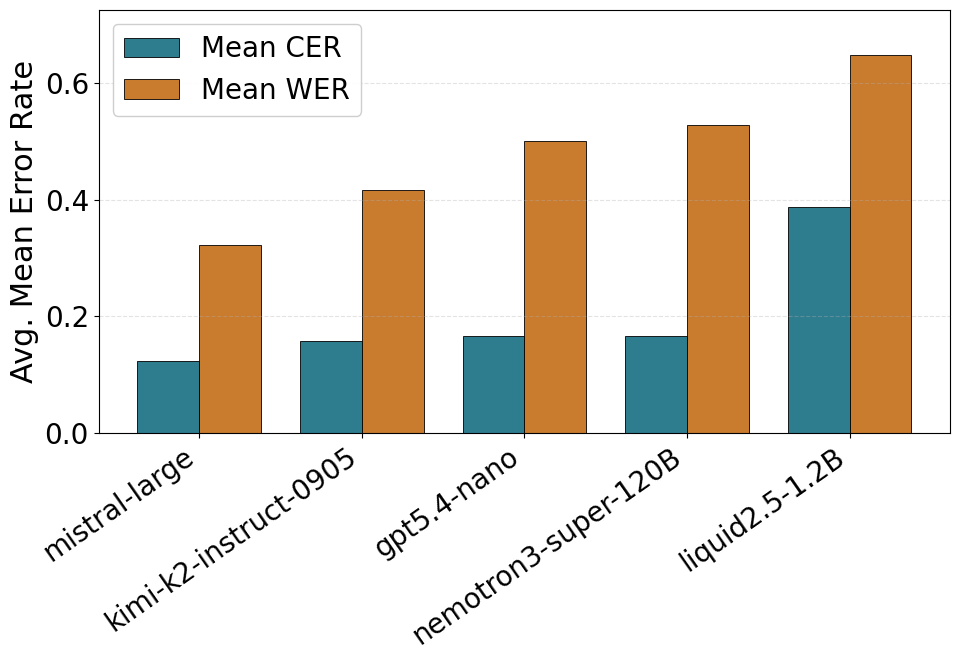

0

In [28]:
%matplotlib inline

"""
Scan model run folders (subdirectories) and plot mean CER / WER from each folder's summary CSV.

Looks for `summary.csv` or `summary_*_api.csv` in each immediate subdirectory.
Model name = folder name. Corrected metrics = any `*_cer` / `*_wer` columns except `raw_*`.
"""

from __future__ import annotations

import argparse
import csv
import sys
from pathlib import Path
from statistics import mean


def find_summary_csv(folder: Path) -> Path | None:
    direct = folder / "summary.csv"
    if direct.is_file():
        return direct
    matches = sorted(folder.glob("summary_*_api.csv"))
    if matches:
        return matches[0]
    return None


def model_metric_columns(fieldnames: list[str]) -> tuple[str, str]:
    cer = [c for c in fieldnames if c.endswith("_cer") and c != "raw_cer"]
    wer = [c for c in fieldnames if c.endswith("_wer") and c != "raw_wer"]
    if len(cer) != 1 or len(wer) != 1:
        raise ValueError(
            f"Expected exactly one model CER and one model WER column; got cer={cer!r} wer={wer!r}"
        )
    return cer[0], wer[0]


def to_float(val: str | None) -> float | None:
    if val is None or str(val).strip() == "":
        return None
    try:
        return float(val)
    except ValueError:
        return None


def mean_cer_wer(summary_path: Path) -> tuple[float, float]:
    with summary_path.open(newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        rows = list(reader)
    if not rows:
        raise ValueError(f"No rows in {summary_path}")
    cer_col, wer_col = model_metric_columns(reader.fieldnames or [])

    cers: list[float] = []
    wers: list[float] = []
    for row in rows:
        c = to_float(row.get(cer_col))
        w = to_float(row.get(wer_col))
        if c is None or w is None:
            continue
        cers.append(c)
        wers.append(w)
    if not cers:
        raise ValueError(f"No numeric CER/WER rows in {summary_path}")
    return mean(cers), mean(wers)


def collect_models(root: Path) -> list[tuple[str, Path]]:
    skip = {
        ".git",
        "__pycache__",
        "outputs",
        "ground-truth",
        ".venv",
        "venv",
        "node_modules",
    }
    out: list[tuple[str, Path]] = []
    for p in sorted(root.iterdir()):
        if not p.is_dir():
            continue
        if p.name.startswith(".") or p.name in skip:
            continue
        sc = find_summary_csv(p)
        if sc:
            out.append((p.name, sc))
    return out


def main() -> int:
    parser = argparse.ArgumentParser(description="Bar plot of mean CER/WER per model folder.")
    parser.add_argument(
        "--root",
        type=Path,
        default=Path.cwd(),
        help="Project root containing model subfolders (default: current working directory).",
    )
    parser.add_argument(
        "-o",
        "--output",
        type=Path,
        default=None,
        help="PNG path (default: <root>/model_comparison_cer_wer.png).",
    )
    args = parser.parse_args([])
    root = args.root.resolve()
    out_path = args.output or (root / "model_comparison_cer_wer.png")

    try:
        import matplotlib.pyplot as plt
        import matplotlib as mpl
        import numpy as np
    except ImportError:
        print("Install matplotlib and numpy: pip install matplotlib numpy", file=sys.stderr)
        return 1

    base = 20
    mpl.rcParams.update(
        {
            "font.size": base,
            "axes.titlesize": base + 2,
            "axes.labelsize": base + 2,
            "xtick.labelsize": base,
            "ytick.labelsize": base,
            "legend.fontsize": base,
        }
    )

    models = collect_models(root)
    if not models:
        print(f"No model folders with summary CSV found under {root}", file=sys.stderr)
        return 1

    names: list[str] = []
    cers: list[float] = []
    wers: list[float] = []
    for name, summary_path in models:
        try:
            mc, mw = mean_cer_wer(summary_path)
        except ValueError as e:
            print(f"Skip {name}: {e}", file=sys.stderr)
            continue
        names.append(name)
        cers.append(mc)
        wers.append(mw)

    if not names:
        return 1

    # Sort by mean CER (lower is better) for a sensible left-to-right order
    order = sorted(range(len(names)), key=lambda i: cers[i])
    names = [names[i] for i in order]
    cers = [cers[i] for i in order]
    wers = [wers[i] for i in order]

    x = np.arange(len(names))
    width = 0.38

    fig, ax = plt.subplots(figsize=(max(10, 1.4 * len(names)), 7))
    ax.bar(x - width / 2, cers, width, label="Mean CER", color="#2e7d8f", edgecolor="black", linewidth=0.6)
    ax.bar(x + width / 2, wers, width, label="Mean WER", color="#c97b2e", edgecolor="black", linewidth=0.6)

    ax.set_ylabel("Avg. Mean Error Rate")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=35, ha="right")
    ax.tick_params(axis="both", which="major", labelsize=base)
    ax.legend(loc="upper left", framealpha=0.95)
    ax.set_ylim(0, max(max(cers), max(wers)) * 1.12 + 1e-6)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    fig.tight_layout()
    fig.savefig(out_path, dpi=600, bbox_inches="tight")
    print(f"Saved {out_path}")
    plt.show()
    return 0


main()
